# 02 - Descriptive Analysis

Compute NEPSE returns, summary statistics, ARCH effects, and event-period plots.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import het_arch

plt.style.use("seaborn-v0_8-whitegrid")

df = pd.read_csv("data_nepse_cleaned.csv", parse_dates=["date_ad"])
df = df.sort_values("date_ad").set_index("date_ad")
df["log_return"] = np.log(df["index_value"] / df["index_value"].shift(1))
df["log_return_pct"] = df["log_return"] * 100
df["rv_30d_annualized_pct"] = df["log_return"].rolling(30).std() * np.sqrt(252) * 100
df.head()


,index_value,absolute_change,percentage_change,calendar_gap_days,is_long_gap,log_return,log_return_pct,rv_30d_annualized_pct
date_ad,,,,,,,,
2015-01-01,903.68,1.35,0.15,NaN,False,NaN,NaN,NaN
2015-01-04,917.50,13.82,1.53,3.0,False,0.015177,1.517726,NaN
2015-01-05,919.77,2.27,0.25,1.0,False,0.002471,0.247106,NaN
2015-01-06,917.41,-2.36,-0.26,1.0,False,-0.002569,-0.256916,NaN
2015-01-07,924.54,7.13,0.78,1.0,False,0.007742,0.774183,NaN


In [2]:
summary = df[["index_value", "log_return_pct", "rv_30d_annualized_pct"]].describe()
summary


,index_value,log_return_pct,rv_30d_annualized_pct
count,2596.000000,2595.000000,2566.000000
mean,1861.045023,0.043307,19.238354
std,617.071045,1.315896,7.819561
min,837.830000,-6.226214,7.045147
25%,1283.632500,-0.647765,13.334114
50%,1815.990000,-0.039629,17.959337
75%,2522.237500,0.649648,24.041856
max,3198.600000,5.884603,54.013002


In [3]:
returns = df["log_return_pct"].dropna()
arch_lm_stat, arch_lm_pvalue, f_stat, f_pvalue = het_arch(returns, nlags=12)
arch_test = pd.DataFrame(
    {
        "statistic": [arch_lm_stat, f_stat],
        "p_value": [arch_lm_pvalue, f_pvalue],
    },
    index=["ARCH LM", "ARCH F"],
)
arch_test


,statistic,p_value
ARCH LM,278.176033,1.769661e-52
ARCH F,25.848410,1.135430e-55


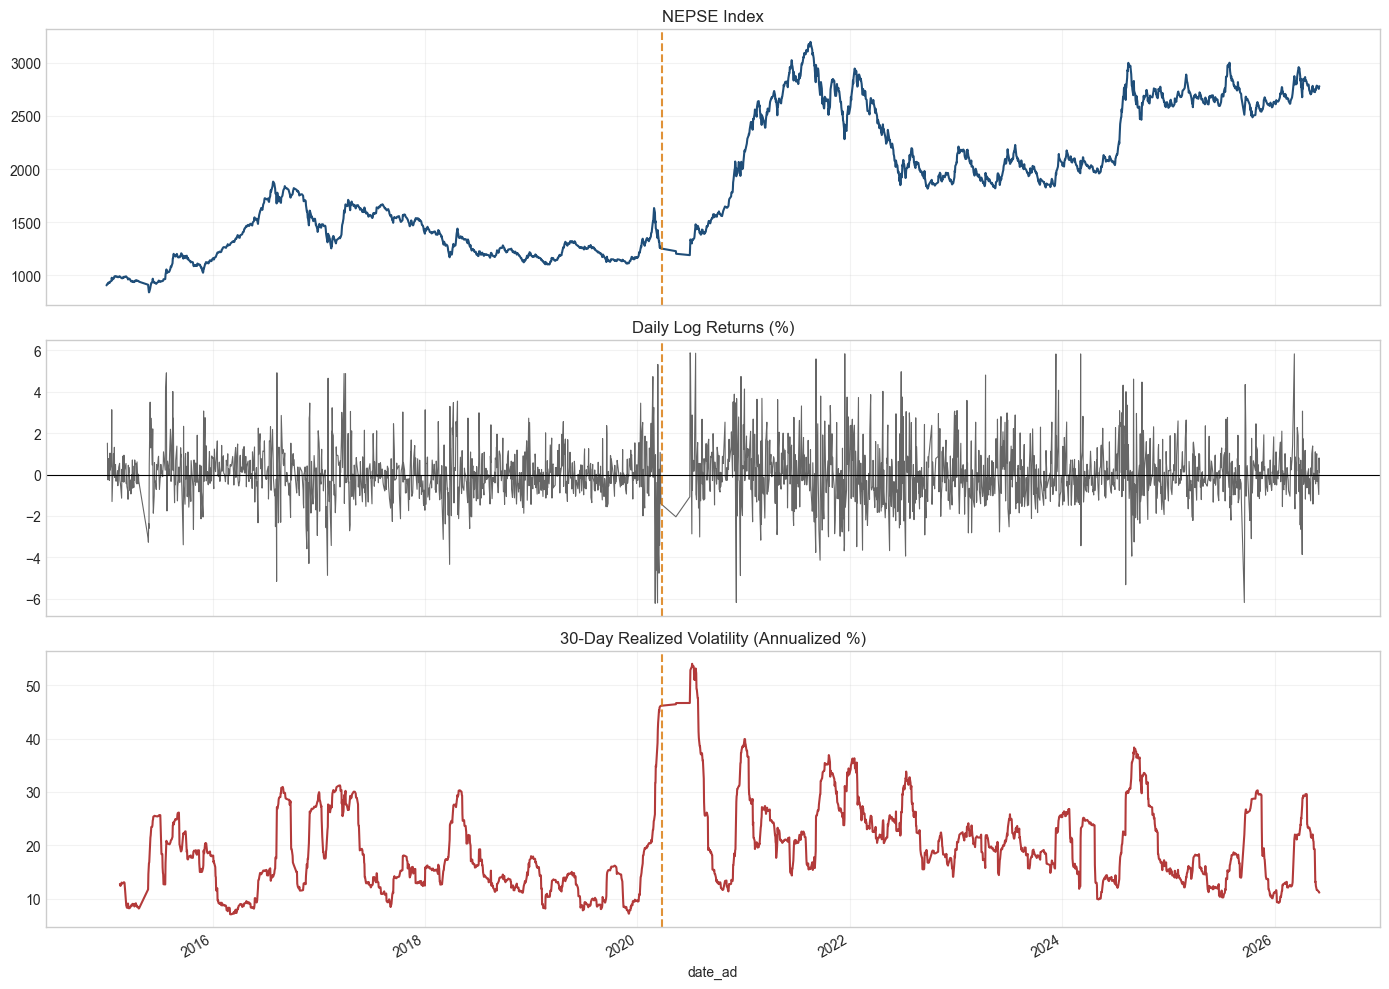

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
df["index_value"].plot(ax=axes[0], color="#1f4e79")
axes[0].set_title("NEPSE Index")
df["log_return_pct"].plot(ax=axes[1], color="#666666", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Daily Log Returns (%)")
df["rv_30d_annualized_pct"].plot(ax=axes[2], color="#b33a3a")
axes[2].set_title("30-Day Realized Volatility (Annualized %)")

for ax in axes:
    ax.axvline(pd.Timestamp("2020-03-24"), color="#d97706", linestyle="--", alpha=0.8)
    ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig("02_descriptive_analysis.png", dpi=180, bbox_inches="tight")
plt.show()


In [5]:
df.to_csv("data_nepse_returns.csv")
print("Saved returns data to data_nepse_returns.csv")


Saved returns data to data_nepse_returns.csv
